In [2]:
import numpy as np #used for arrays and numerical functions
import pandas as pd #used for reading a data file
import matplotlib.pyplot as plt #used for graphing
from io import StringIO #used to convert string to a dataframe

# Plotting Functions and Data

Under the hood, when we plot either a function or data using Python we are doing the same thing. We are generating a list of points (usually 2D points with an x and y position) and then telling the computer to draw those points on a set of axes. There are a lot of style options available to us to customize the output. What shape do we want the points? Do we want them connected by a smooth line? What style and color should the line be? All of these are controlled by us. This notebook will familiarize you with the options available as well has how to get your data, whether it comes from a function or an external file, into the form required to plot it.

## Review: Functions in python

In the last notebook, you learned to plot a mathematical function (i.e. an emperical model). Our example was a mathematical function relating brain mass to body mass of mammals:

$$m = 8.5M^{0.75}$$

where $m$ is the brain mass in grams and $M$ is the body mass in kilograms. Using this model, you can predict the brain mass of a mammal (the dependent variable) if you know its body mass (the independent variable).

First you created a Python function `brain_mass` that takes a body mass `M` and calculates and returns a brain mass `m`. In the example below, we use the `lambda` function as a way to create the `brain_mass` function. Then, we use an f-string to insert the variable `m` into our string and print it with 1 significant figure.


In [3]:
brain_mass = lambda M: 8.5*M**0.75 #g
    
m = brain_mass(100)
print(f"Our model predicts that a 100 kg mammal would have a brain_mass of {m:.1f} grams.")

Our model predicts that a 100 kg mammal would have a brain_mass of 268.8 grams.


In the example above, we send the value 100 to the `brain_mass` function. Equivalently, we can define a variable `M`, give it the value 100, and send `M` to our function. It gives the same result, of course.

In [4]:
brain_mass = lambda M: 8.5*M**0.75 #g

M = 100
m = brain_mass(M)
print(f"Our model predicts that a 100 kg mammal would have a brain_mass of {m:.1f} grams.")

Our model predicts that a 100 kg mammal would have a brain_mass of 268.8 grams.


Then, we used this Python function to calculate and plot the brain mass for an array of different values of `M`.

In [ ]:
# calculate
M = np.array([1, 5, 10, 100, 500, 1000])
m = brain_mass(M)
print(f"Body masses in kg: {M}")
print(f"Brain masses in g: {m}")

# plot
fig = plt.figure()
plt.title('Brain Mass vs. Body Mass for Mammals')
plt.xlabel('Body Mass (kg)')
plt.ylabel('Brain Mass (g)')
plt.plot(M, m, 'b.') #this specifies the data to plot in the format (horizontal, vertical)
plt.show()

## Exercise 1: Using `linespace` 


Another way to create an array of values of the independent variable is to use the numpy `1inspace()` function. The syntax is:

```
np.linspace(min, max, number of points)

```

where `np` is the alias we used for `numpy` when importing this package in the first code cell in the notebook.

As an example, let's create 100 values of `M` from 0 to 1000 and calculate and plot the brain mass for each value of `M`. Normally it's not necessary to print all of these values. But for clarity, I print them below.

In [ ]:
# calculate
M = np.linspace(0,1000,100)
m = brain_mass(M)
print(f"Body masses in kg: {M}")
print(f"Brain masses in g: {m}")

# plot
fig = plt.figure()
plt.title('Brain Mass vs. Body Mass for Mammals')
plt.xlabel('Body Mass (kg)')
plt.ylabel('Brain Mass (g)')
plt.plot(m, M, 'b.') #this specifies the data to plot in the format (horizontal, vertical)
plt.show()

### Exercise

Plot 500 data points for brain mass vs. body mass for mammals with a body mass less than 50 kg. (Do not print the values of the independent and dependent variables. Just plot it.)

## Exercise 2: Style options with `plot`

The plot command used in the example of brain mass and body mass

```python

plt.plot(m, M, 'b.')

```

takes as input the data array for the horizontal axis, the data array for the vertical axis, and parameters to determine the type and color of the data point. In this case ``b`` is for blue and ``.`` is for a small filled circle.

### Exercise

In the program below, change the `b.` to `r.` and see what happens.

### Exercise

Try `r-` and see what happens.

### Exercise

Try `mo` and see what happens.

### Exercise

Try `m--` and see what happens.



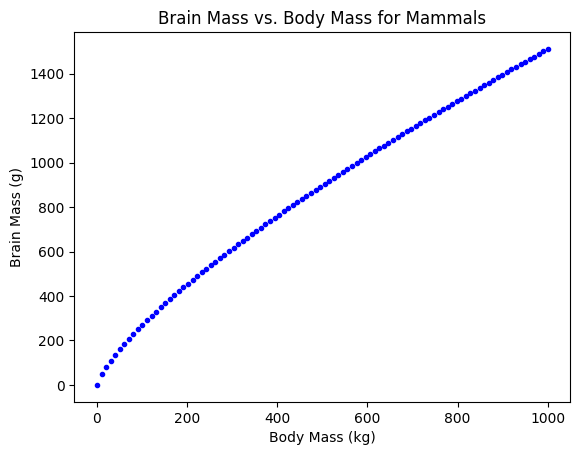

In [7]:
# calculate
M = np.linspace(0,1000,100)
m = brain_mass(M)

# plot
fig = plt.figure()
plt.title('Brain Mass vs. Body Mass for Mammals')
plt.xlabel('Body Mass (kg)')
plt.ylabel('Brain Mass (g)')
plt.plot(M, m, 'b.') #this specifies the data to plot in the format (horizontal, vertical)
plt.show()

This is how you specify color and marker type.

Here are letters for various colors.

| letter | color || letter | color |
| -- | -- | -- |  -- | -- |
|b | blue || m | magenta |
|g  |  green  ||  y  |  yellow  | 
|r  |  red || k  |  black |
|c | cyan || w | white |

Here are symbols for various types of markers.

| symbol | marker || symbol | marker |
| -- | -- | -- |  -- | -- |
| `s` | square marker | | `p` | pentagon marker |
|`D` | diamond marker | | `d` | thin diamond marker|
|`*` | star marker | | `+` | plus marker|
|`h` | hexagon1 marker | | `H` | hexagon2 marker|
|`x` | x marker | | | | |

Use `-` for solid line and `--` for a dashed line.

### Exercise

In the cell below, try plotting the graph with various colors, marker types, and lines.

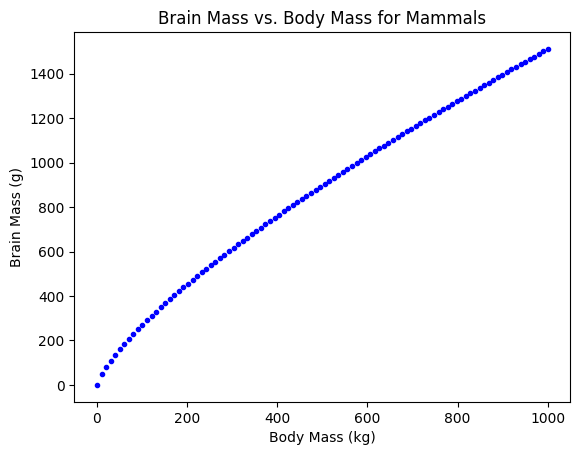

In [19]:
# calculate
M = np.linspace(0,1000,100)
m = brain_mass(M)

# plot
plt.title('Brain Mass vs. Body Mass for Mammals')
plt.xlabel('Body Mass (kg)')
plt.ylabel('Brain Mass (g)')
plt.plot(M, m, 'b.') #this specifies the data to plot in the format (horizontal, vertical)
plt.show()

## Exercise 3

In physics lab, an object hangs from a spring and oscillates up and down. It's height $h$ above the table in meters is described by

$$h=0.05\cos(\pi t + 1.1)+0.1$$

where $t$ is in seconds and the angle (the argument of the cosine function) is in radians.

1. Plot 400 data points for the time `t` between 0 and 6 seconds. First, plot points. Then, choose another color and plot a solid line.
2. Change your graph so it is still a solid line but only plots 10 data points. Then change it to plot 1000 data points. Do you notice a difference in the smoothness of the line?

## Exercise 4

Find the formula to convert temperature in degrees Fahrenheit to the temperature in degrees Celsius. Plot a graph of the temperature in Celsius as a function of the temperature in Fahrenheit for temperatures ranging from -40 degrees Fahrenheit to 115 degrees Fahrenheit, which is an approximate range of low to high temperatures in the U.S. in one year. **Your graph should have a proper title and axis labels.**

## Exercise 5

Find the formula to convert temperature in degrees Celsius to the temperature in degrees Fahrenheit. Plot a graph of the temperature in Fahrenheit as a function of the temperature in Celsius for temperatures ranging from an annual low to an annual high for Czech Replublic. **Your graph should have a proper title and axis labels.**

# Plotting data



In the last half of the notebook you will learn how to read and graph data that is stored in a tab-delimited format in a text file.

In this first example, we'll plot a data set for absorption of light for bacteria growing in a liquid medium. Various samples might look like this:

<img src="https://github.com/atitus/STLinATL/raw/master/workshop2/03-plot-data/bacteria.png" width="500" align="center">

<font size=-1>Image credit: <a href="https://www.jove.com/video/56197/precise-high-throughput-analysis-of-bacterial-growth" target="_new">Precise, High-throughput Analysis of Bacterial Growth</a> by Masaomi Kurokawal and Bei-Wen Ying.</font>

But there are many libraries of free data sets, like [this compilation at NCSU](https://www.lib.ncsu.edu/teaching-and-learning-datasets), to choose from.

Our data is stored in a tab-delimited file on github ([https://raw.githubusercontent.com/anthoak13/HNR-1303-F23/main/unit-03/03-02-plotting/bacterial-population-data.txt](https://raw.githubusercontent.com/anthoak13/HNR-1303-F23/main/unit-03/03-02-plotting/bacterial-population-data.txt)). 

We will read it using a python library called [`pandas`](https://pandas.pydata.org/docs/index.html), which we imported in the first cell in this notebook using the alias `pd`. Pandas is a useful tool for the manipulation of data. Below, we will start by loading our data into a `dataframe` which we have given the name `df`. A [`dataframe`](https://www.geeksforgeeks.org/python-pandas-dataframe/#) is an object that contains a list of 2D points, exactly what we need for plotting. We then print out the first few entries in the `dataframe`.


In [5]:
# Read the data file. The result is a dataframe object, which is named df in this case.
df = pd.read_csv('https://raw.githubusercontent.com/anthoak13/HNR-1303-F23/main/unit-03/03-02-plotting/bacterial-population-data.txt', sep='\t')

#print first five rows of data with the header
print(df.head())

   time (min)  absorbance (arb)
0           0             0.022
1          16             0.036
2          32             0.060
3          48             0.101
4          64             0.169


The first line is called the **header** and we can refer to a specific column by its header. This is demonstraited below where we plot this data by assigning a variable name to each column of data we want to plot.

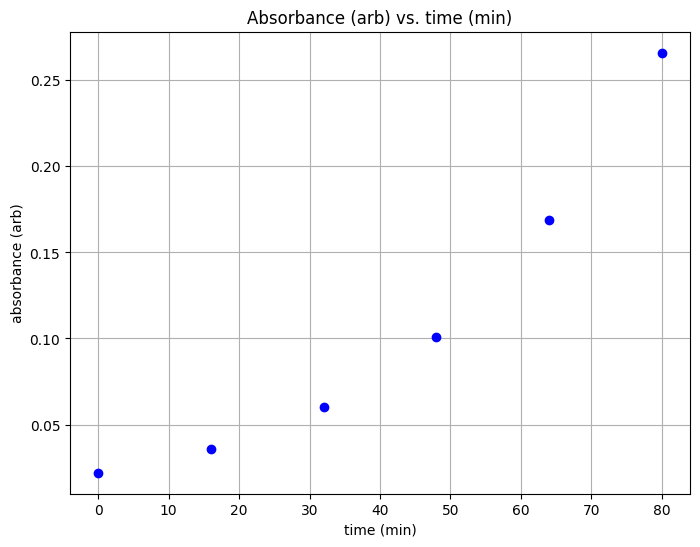

In [7]:
# give variable names to the columns of data
xdata = df['time (min)']
ydata = df['absorbance (arb)']

# plot data
fig = plt.figure(figsize=(8,6))
plt.title('Absorbance (arb) vs. time (min)')
plt.xlabel('time (min)')
plt.ylabel('absorbance (arb)')
plt.grid(which='both', axis='both')
plt.plot(xdata,ydata,'bo') # syntax is (horizontal data , vertical data)
plt.show()

## Exercise 6

Inspired by this recent [New York Times article](https://www.nytimes.com/interactive/2023/09/05/upshot/medicare-budget-threat-receded.html), I attempted to recreate their data for average Medicare expendature per benificiary. I pulled data from the [Census Bureau](https://www.census.gov/history/pdf/medicare1966-2013.pdf) and the Centers for Medicare and Medicaid Services ([here](https://www.cms.gov/data-research/statistics-trends-and-reports/national-health-expenditure-data/historical) and [here](https://data.cms.gov/summary-statistics-on-beneficiary-enrollment/medicare-and-medicaid-reports/medicare-monthly-enrollment)).

In the cell below, the data is read into a `dataframe` and the first few entries are printed. Graph the average Medicare speding per person as a function of year. Your graph should have the proper axis labels.

In [9]:
df = pd.read_csv('https://raw.githubusercontent.com/anthoak13/HNR-1303-F23/main/unit-03/03-02-plotting/MedicareSpending.txt', sep='\t')

#print first five rows of data with the header
print(df.head())

   Year  Spending per person ($)
0  1966                    96.53
1  1967                   252.59
2  1968                   314.52
3  1969                   352.00
4  1970                   376.80


## Exercise 7
Read the file `pole-vaulter.txt` that contains data for HPU alumnus and pole vaulter, Keith Gates, and graph his y-position as a function of x-position. Properly title the graph and label the axes, with units.

In [11]:
df = pd.read_csv('https://raw.githubusercontent.com/anthoak13/HNR-1303-F23/main/unit-03/03-02-plotting/pole-vaulter.txt', sep='\t')
print(df.head())

#Add code for plotting here

   t (s)  x (m)  y (m)
0  0.000 -0.008  0.004
1  0.067  0.547 -0.027
2  0.133  1.070  0.004
3  0.200  1.594 -0.058
4  0.267  2.118 -0.027


## Getting data from a spreadsheet

Sometimes you have data in Excel or on a web page instead of a public file on the internet. In this case, you can copy and paste the data. Here is a template to start from.

I am assuming the data is tab-delimited. But we can also handle comma-delimited or space-delimited data as well. In this case, we would have to change the `sep` value in our `pd.read_csv()` function.

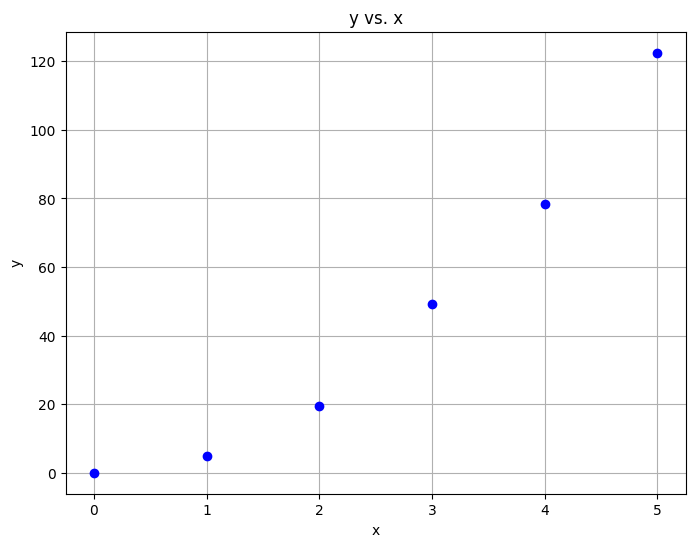

In [12]:

#
# Paste the data you wish to graph in tab-delimited rows in the format:
#
#       xdata <tab> ydata
#
#

# define data
data = StringIO("""x	y
0	0
1	4.9
2	19.6
3	49.1
4	78.4
5	122.5
""") 

# convert data to dataframe
df = pd.read_csv(data, sep ="\t")

# define arrays for the data
xdata = df['x']
ydata = df['y']

# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("y vs. x")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo')
plt.show()

## Exercise 8

I have copied the template above into the cell below so you can just replace the columns of data.

Here is a Google sheet with data. In the first tab, there is data for the growth of yeast cells under different environmental conditions (light).

https://docs.google.com/spreadsheets/d/1jgtMc3TsjziSFCdsdILzIvPbg1H2BESKNkQh-VTcMtw/edit?usp=sharing

Go to the sheet above and do the following:

1. select the first two columns of data for time and yeast population (do not include the column headings)
2. copy the data (cmd-c or ctrl-c)
3. select the data in the cell below and delete it
4. paste the data from the Google sheet. To paste the data without Google doing some fancy formatting, you will want to hold shift while pasting (cmd-shift-v or ctrl-shift-v)

After plotting the data, change the labels and title of the graph.

In [ ]:

#
# Paste the data you wish to graph in tab-delimited rows in the format:
#
#       xdata <tab> ydata
#
#

# define data
data = StringIO("""x	y
0	0
1	4.9
2	19.6
3	49.1
4	78.4
5	122.5
""") 

# convert data to dataframe
df = pd.read_csv(data, sep ="\t")

# define arrays for the data
xdata = df['x']
ydata = df['y']

# plot data and the best-fit function on the same graph
fig = plt.figure(figsize=(8,6))
plt.title("y vs. x")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(which='both', axis='both')
plt.plot(xdata, ydata, 'bo')
plt.show()

## Exercise 9

In the sheet at:

https://docs.google.com/spreadsheets/d/1jgtMc3TsjziSFCdsdILzIvPbg1H2BESKNkQh-VTcMtw/edit?usp=sharing

there are multiple tabs with data. Plot the data for systolic blood pressure vs. age. You should properly label the axes and title the graph.

## Homework: Exercise 1 - done for class today

Search for an empirical model of a system in any area. It could be in science, social science, economics, finance, health, etc. The empirical model must be a mathematical function, and the dependent and independent variables must represent measurable quantities. In other words, the model must describe a real system.

Describe the model with a brief narrative (like the examples above), and use LaTeX to format the mathematical function. On our web site there are:

1. a tutorial with examples for formatting text in markdown.
2. examples of LaTeX to format math.

Your description and result should

1. have links your sources.
1. describe the model as a mathematical function, typeset correctly.
1. define the dependent and independent variables.
1. plot the function for a set of 10 - 20 values of the independent variable.

## Homework: Exercise 2

Find a data set related to your empirical model you found for the previous exercise (the model does not necessarily have to match or describe this data). Plot the data using appropriate axis. Add a markdown cell below providing context and sources for your data. 